In [1]:
import pandas as pd

df_rendement = pd.read_csv("VFAOSTAT_data_fr_8-12-2026.csv")
df_pluie = pd.read_csv("VPOWER_Point_Monthly_20000101_20201231_014d70N_017d04W_LST.csv", skiprows=9)

In [2]:
df_rendement.shape
df_rendement.head(10)

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit (CPC),Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,QCL,Cultures et produits animaux,686,Sénégal,5412,Rendement,142,Arachides non décortiquées,2000,2000,kg/ha,969.1,A,Valeur officielle,NaN
1,QCL,Cultures et produits animaux,686,Sénégal,5412,Rendement,142,Arachides non décortiquées,2001,2001,kg/ha,964.0,A,Valeur officielle,NaN
2,QCL,Cultures et produits animaux,686,Sénégal,5412,Rendement,142,Arachides non décortiquées,2002,2002,kg/ha,320.4,A,Valeur officielle,NaN
3,QCL,Cultures et produits animaux,686,Sénégal,5412,Rendement,142,Arachides non décortiquées,2003,2003,kg/ha,839.7,A,Valeur officielle,NaN
4,QCL,Cultures et produits animaux,686,Sénégal,5412,Rendement,142,Arachides non décortiquées,2004,2004,kg/ha,806.4,A,Valeur officielle,NaN
5,QCL,Cultures et produits animaux,686,Sénégal,5412,Rendement,142,Arachides non décortiquées,2005,2005,kg/ha,910.7,A,Valeur officielle,NaN
6,QCL,Cultures et produits animaux,686,Sénégal,5412,Rendement,142,Arachides non décortiquées,2006,2006,kg/ha,774.9,A,Valeur officielle,NaN
7,QCL,Cultures et produits animaux,686,Sénégal,5412,Rendement,142,Arachides non décortiquées,2007,2007,kg/ha,545.5,A,Valeur officielle,NaN
8,QCL,Cultures et produits animaux,686,Sénégal,5412,Rendement,142,Arachides non décortiquées,2008,2008,kg/ha,873.8,A,Valeur officielle,NaN
9,QCL,Cultures et produits animaux,686,Sénégal,5412,Rendement,142,Arachides non décortiquées,2009,2009,kg/ha,975.0,A,Valeur officielle,NaN


In [4]:
df_rendement.columns

Index(['Code Domaine', 'Domaine', 'Code zone (M49)', 'Zone', 'Code Élément',
       'Élément', 'Code Produit (CPC)', 'Produit', 'Code année', 'Année',
       'Unité', 'Valeur', 'Symbole', 'Description du Symbole', 'Note'],
      dtype='str')

In [5]:
df_rendement['Produit'].unique()

<StringArray>
['Arachides non décortiquées', 'Maïs', 'Mils', 'Riz', 'Sorgho']
Length: 5, dtype: str

In [8]:
df_pluie.shape
df_pluie.head(10)

,PARAMETER,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN
0,PRECTOTCORR_SUM,2000,0.94,0.85,0.00,0.16,0.34,5.28,69.39,119.89,97.82,87.97,0.08,0.24,382.96
1,PRECTOTCORR_SUM,2001,0.01,0.43,0.01,0.08,0.19,10.44,91.73,120.88,81.42,10.05,4.36,0.62,320.22
2,PRECTOTCORR_SUM,2002,20.64,0.46,0.83,0.07,0.20,10.16,8.75,101.96,101.12,33.37,0.50,3.27,281.33
3,PRECTOTCORR_SUM,2003,0.29,0.43,0.09,0.63,0.19,20.26,57.57,139.07,150.07,54.05,0.11,0.44,423.20
4,PRECTOTCORR_SUM,2004,2.18,0.05,0.23,0.49,0.70,16.81,65.47,161.97,131.07,18.30,4.22,0.38,401.87
5,PRECTOTCORR_SUM,2005,0.44,8.08,0.24,1.13,1.51,30.82,147.28,220.36,157.46,72.93,0.49,0.30,641.04
6,PRECTOTCORR_SUM,2006,21.31,2.86,0.30,0.04,1.94,21.01,63.80,212.21,191.29,60.72,0.42,0.86,576.76
7,PRECTOTCORR_SUM,2007,0.12,0.05,0.68,0.51,1.30,7.47,93.14,199.64,189.57,18.43,0.30,0.27,511.48
8,PRECTOTCORR_SUM,2008,0.69,9.54,0.03,0.07,1.42,22.73,214.29,309.67,206.82,43.81,0.11,0.09,809.27
9,PRECTOTCORR_SUM,2009,0.25,0.96,0.11,0.07,0.24,23.01,155.01,395.77,222.91,27.95,4.66,1.75,832.69


In [9]:
df_pluie_long = df_pluie.melt(
    id_vars=['YEAR'],           # la colonne qu'on garde telle quelle
    value_vars=['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'],  # les colonnes à "empiler"
    var_name='mois',            # nom de la nouvelle colonne qui contiendra JAN, FEB, etc.
    value_name='precipitation'  # nom de la nouvelle colonne qui contiendra les valeurs
)

In [10]:
df_pluie_long.shape
df_pluie_long.head(15)

,YEAR,mois,precipitation
0,2000,JAN,0.94
1,2001,JAN,0.01
2,2002,JAN,20.64
3,2003,JAN,0.29
4,2004,JAN,2.18
5,2005,JAN,0.44
6,2006,JAN,21.31
7,2007,JAN,0.12
8,2008,JAN,0.69
9,2009,JAN,0.25


In [11]:
mois_vers_numero = {
    'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
    'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
}

df_pluie_long['mois_num'] = df_pluie_long['mois'].map(mois_vers_numero)

In [12]:
df_pluie_long = df_pluie_long.sort_values(['YEAR', 'mois_num']).reset_index(drop=True)

In [13]:
df_pluie_long.head(15)

,YEAR,mois,precipitation,mois_num
0,2000,JAN,0.94,1
1,2000,FEB,0.85,2
2,2000,MAR,0.00,3
3,2000,APR,0.16,4
4,2000,MAY,0.34,5
5,2000,JUN,5.28,6
6,2000,JUL,69.39,7
7,2000,AUG,119.89,8
8,2000,SEP,97.82,9
9,2000,OCT,87.97,10


In [3]:
df_mil_rendement = df_rendement[df_rendement['Produit'] == 'Mils']
df_mil_rendement[['Année', 'Valeur']]

,Année,Valeur
42,2000,712.7
43,2001,694.9
44,2002,506.1
45,2003,732.9
46,2004,471.3
47,2005,760.0
48,2006,660.6
49,2007,464.2
50,2008,767.5
51,2009,770.3


In [14]:
pluie_annuelle = df_pluie_long.groupby('YEAR')['precipitation'].sum()

In [15]:
pluie_annuelle

YEAR
2000    382.96
2001    320.22
2002    281.33
2003    423.20
2004    401.87
2005    641.04
2006    576.76
2007    511.48
2008    809.27
2009    832.69
2010    676.68
2011    509.86
2012    469.43
2013    562.35
2014    474.31
2015    793.85
2016    486.69
2017    437.82
2018    456.31
2019    504.99
2020    996.14
Name: precipitation, dtype: float64

In [16]:
pluie_annuelle_df = pluie_annuelle.reset_index()
pluie_annuelle_df.columns = ['Annee', 'precipitation_totale']

In [17]:
mil_df = df_mil_rendement[['Année', 'Valeur']].copy()
mil_df.columns = ['Annee', 'rendement']

In [18]:
df_final = pd.merge(mil_df, pluie_annuelle_df, on='Annee')

In [19]:
df_final

,Annee,rendement,precipitation_totale
0,2000,712.7,382.96
1,2001,694.9,320.22
2,2002,506.1,281.33
3,2003,732.9,423.20
4,2004,471.3,401.87
5,2005,760.0,641.04
6,2006,660.6,576.76
7,2007,464.2,511.48
8,2008,767.5,809.27
9,2009,770.3,832.69


In [20]:
df_final['rendement'].corr(df_final['precipitation_totale'])

np.float64(0.4994513388704887)

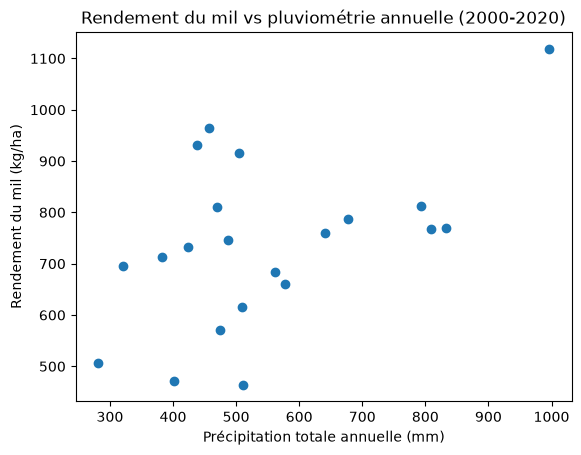

In [21]:
import matplotlib.pyplot as plt

plt.scatter(df_final['precipitation_totale'], df_final['rendement'])
plt.xlabel("Précipitation totale annuelle (mm)")
plt.ylabel("Rendement du mil (kg/ha)")
plt.title("Rendement du mil vs pluviométrie annuelle (2000-2020)")
plt.show()

In [22]:
df_final[df_final['precipitation_totale'] > 900]

,Annee,rendement,precipitation_totale
20,2020,1119.0,996.14


In [23]:
df_sans_2020 = df_final[df_final['Annee'] != 2020]
df_sans_2020['rendement'].corr(df_sans_2020['precipitation_totale'])

np.float64(0.2860386809600117)